In [2]:
## importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix


## DATA COLLECTION

In [3]:
## read dataset
data = pd.read_csv("csv_result-.csv")
df=pd.DataFrame(data)
df

,id,'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',...,'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
0,1,0,tcp,ftp_data,SF,491,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,2,0,udp,other,SF,146,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,3,0,tcp,private,S0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,4,0,tcp,http,SF,232,8153,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,5,0,tcp,http,SF,199,420,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,125969,0,tcp,private,S0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
125969,125970,8,udp,private,SF,105,145,0,0,0,...,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal
125970,125971,0,tcp,smtp,SF,2231,384,0,0,0,...,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal
125971,125972,0,tcp,klogin,S0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


In [4]:
df=df.sample(n=5000,random_state=42)
df

,id,'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',...,'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
378,379,0,udp,domain_u,SF,36,0,0,0,0,...,171,1.00,0.00,1.00,0.01,0.00,0.00,0.00,0.0,normal
32038,32039,0,tcp,http,S0,0,0,0,0,0,...,44,0.17,0.05,0.01,0.00,1.00,1.00,0.00,0.0,anomaly
86399,86400,0,tcp,pop_3,S0,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.00,1.00,0.00,0.0,anomaly
74412,74413,0,tcp,private,REJ,0,0,0,0,0,...,27,0.11,0.07,0.00,0.00,0.00,0.00,1.00,1.0,anomaly
52951,52952,0,tcp,private,RSTR,0,0,0,0,0,...,1,0.01,0.64,0.64,0.00,0.04,0.00,0.63,1.0,anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37413,37414,0,tcp,ftp_data,SF,1153,0,0,0,0,...,6,0.16,0.08,0.16,0.00,0.00,0.00,0.00,0.0,normal
106329,106330,0,udp,other,SF,147,0,0,0,0,...,2,0.01,0.57,0.94,0.00,0.00,0.00,0.00,0.0,normal
86083,86084,0,udp,domain_u,SF,46,46,0,0,0,...,245,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.0,normal
36226,36227,0,udp,domain_u,SF,43,69,0,0,0,...,255,1.00,0.00,0.01,0.00,0.00,0.00,0.00,0.0,normal


In [5]:
## shape of dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (5000, 43)


In [6]:
df.columns = df.columns.str.replace("'", "").str.strip().str.lower()
print(df.columns)

Index(['id', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')


In [7]:
## checking null values in dataset
df.isnull().sum()

id                             0
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_r

In [8]:
## checking duplicate values in dataset
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [9]:
## checking structural representation
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 378 to 101372
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           5000 non-null   int64  
 1   duration                     5000 non-null   int64  
 2   protocol_type                5000 non-null   object 
 3   service                      5000 non-null   object 
 4   flag                         5000 non-null   object 
 5   src_bytes                    5000 non-null   int64  
 6   dst_bytes                    5000 non-null   int64  
 7   land                         5000 non-null   int64  
 8   wrong_fragment               5000 non-null   int64  
 9   urgent                       5000 non-null   int64  
 10  hot                          5000 non-null   int64  
 11  num_failed_logins            5000 non-null   int64  
 12  logged_in                    5000 non-null   int64  
 13  num_compromised    

In [10]:
## checking statical representation
df.describe()

,id,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,62391.801600,341.416000,1.324716e+04,1792.473600,0.00060,0.027600,0.0,0.164800,0.002400,0.378400,...,182.509600,113.113400,0.512864,0.088378,0.151014,0.031588,0.294038,0.288454,0.119084,0.120694
std,36462.066247,2778.855578,3.229827e+05,13072.374812,0.02449,0.282231,0.0,1.847464,0.079972,0.485037,...,99.685936,110.229651,0.448418,0.195799,0.311296,0.109488,0.448115,0.450541,0.306473,0.320342
min,34.000000,0.000000,0.000000e+00,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30744.500000,0.000000,0.000000e+00,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,...,81.000000,9.000000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62355.500000,0.000000,4.300000e+01,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,...,255.000000,59.500000,0.470000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,94012.500000,0.000000,2.602500e+02,403.000000,0.00000,0.000000,0.0,0.000000,0.000000,1.000000,...,255.000000,255.000000,1.000000,0.070000,0.070000,0.010000,1.000000,1.000000,0.000000,0.000000
max,125953.000000,42492.000000,1.882898e+07,574784.000000,1.00000,3.000000,0.0,30.000000,5.000000,1.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df['class'].value_counts()

class
normal     2640
anomaly    2360
Name: count, dtype: int64

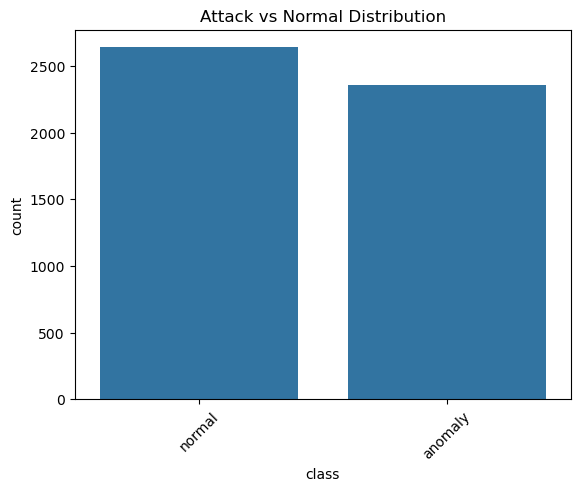

In [12]:
plt.figure()
sns.countplot(x='class', data=df)
plt.xticks(rotation=45)
plt.title("Attack vs Normal Distribution")
plt.show()

In [13]:
le = LabelEncoder()

In [14]:
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.head()

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
378,379,0,2,11,8,36,0,0,0,0,...,171,1.00,0.00,1.00,0.01,0.00,0.0,0.00,0.0,1
32038,32039,0,1,22,4,0,0,0,0,0,...,44,0.17,0.05,0.01,0.00,1.00,1.0,0.00,0.0,0
86399,86400,0,1,42,4,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.00,1.0,0.00,0.0,0
74412,74413,0,1,44,0,0,0,0,0,0,...,27,0.11,0.07,0.00,0.00,0.00,0.0,1.00,1.0,0
52951,52952,0,1,44,3,0,0,0,0,0,...,1,0.01,0.64,0.64,0.00,0.04,0.0,0.63,1.0,0


# min max scaler

In [15]:
df1=pd.DataFrame()
df1=(df-df.min())/(df.max()-df.min())
df1

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
378,0.002740,0.0,1.0,0.180328,0.888889,0.000002,0.000000,0.0,0.0,NaN,...,0.670588,1.00,0.00,1.00,0.01,0.00,0.00,0.00,0.0,1.0
32038,0.254171,0.0,0.5,0.360656,0.444444,0.000000,0.000000,0.0,0.0,NaN,...,0.172549,0.17,0.05,0.01,0.00,1.00,1.00,0.00,0.0,0.0
86399,0.685885,0.0,0.5,0.688525,0.444444,0.000000,0.000000,0.0,0.0,NaN,...,0.078431,0.08,0.06,0.00,0.00,1.00,1.00,0.00,0.0,0.0
74412,0.590689,0.0,0.5,0.721311,0.000000,0.000000,0.000000,0.0,0.0,NaN,...,0.105882,0.11,0.07,0.00,0.00,0.00,0.00,1.00,1.0,0.0
52951,0.420254,0.0,0.5,0.721311,0.333333,0.000000,0.000000,0.0,0.0,NaN,...,0.003922,0.01,0.64,0.64,0.00,0.04,0.00,0.63,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37413,0.296858,0.0,0.5,0.311475,0.888889,0.000061,0.000000,0.0,0.0,NaN,...,0.023529,0.16,0.08,0.16,0.00,0.00,0.00,0.00,0.0,1.0
106329,0.844162,0.0,1.0,0.655738,0.888889,0.000008,0.000000,0.0,0.0,NaN,...,0.007843,0.01,0.57,0.94,0.00,0.00,0.00,0.00,0.0,1.0
86083,0.683376,0.0,1.0,0.180328,0.888889,0.000002,0.000080,0.0,0.0,NaN,...,0.960784,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.0,1.0
36226,0.287431,0.0,1.0,0.180328,0.888889,0.000002,0.000120,0.0,0.0,NaN,...,1.000000,1.00,0.00,0.01,0.00,0.00,0.00,0.00,0.0,1.0


In [16]:
#df1.nunique()

# standard scaler

In [17]:
df2=pd.DataFrame()
df2=(df-df.mean())/df.std()
df2

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
378,-1.700748,-0.122862,2.143961,-1.197017,0.765722,-0.040904,-0.137119,-0.0245,-0.097792,NaN,...,0.525145,1.086343,-0.451371,2.727262,-0.197172,-0.656166,-0.640239,-0.388563,-0.376767,0.945389
32038,-0.832449,-0.122862,-0.147085,-0.436145,-0.723865,-0.041015,-0.137119,-0.0245,-0.097792,NaN,...,-0.626995,-0.764608,-0.196007,-0.452990,-0.288506,1.575402,1.579315,-0.388563,-0.376767,-1.057554
86399,0.658443,-0.122862,-0.147085,0.947257,-0.723865,-0.041015,-0.137119,-0.0245,-0.097792,NaN,...,-0.844722,-0.965313,-0.144934,-0.485114,-0.288506,1.575402,1.579315,-0.388563,-0.376767,-1.057554
74412,0.329691,-0.122862,-0.147085,1.085598,-2.213451,-0.041015,-0.137119,-0.0245,-0.097792,NaN,...,-0.781218,-0.898411,-0.093862,-0.485114,-0.288506,-0.656166,-0.640239,2.874366,2.744902,-1.057554
52951,-0.258894,-0.122862,-0.147085,1.085598,-1.096261,-0.041015,-0.137119,-0.0245,-0.097792,NaN,...,-1.017089,-1.121417,2.817287,1.570807,-0.288506,-0.566903,-0.640239,1.667082,2.744902,-1.057554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37413,-0.685035,-0.122862,-0.147085,-0.643656,0.765722,-0.037445,-0.137119,-0.0245,-0.097792,NaN,...,-0.971729,-0.786908,-0.042789,0.028866,-0.288506,-0.656166,-0.640239,-0.388563,-0.376767,0.945389
106329,1.205039,-0.122862,2.143961,0.808917,0.765722,-0.040560,-0.137119,-0.0245,-0.097792,NaN,...,-1.008017,-1.121417,2.459777,2.534520,-0.288506,-0.656166,-0.640239,-0.388563,-0.376767,0.945389
86083,0.649777,-0.122862,2.143961,-1.197017,0.765722,-0.040873,-0.133600,-0.0245,-0.097792,NaN,...,1.196471,0.997140,-0.400298,-0.452990,-0.288506,-0.656166,-0.640239,-0.388563,-0.376767,0.945389
36226,-0.717590,-0.122862,2.143961,-1.197017,0.765722,-0.040882,-0.131841,-0.0245,-0.097792,NaN,...,1.287191,1.086343,-0.451371,-0.452990,-0.288506,-0.656166,-0.640239,-0.388563,-0.376767,0.945389


## DATA SELECTION

# Data selction by forward feature selection 

In [18]:
df1=df1.loc[:,df1.nunique()>1]
df2=df2.loc[:,df2.nunique()>1]

In [19]:
df1.nunique()

id                             5000
duration                        196
protocol_type                     3
service                          62
flag                             10
src_bytes                       685
dst_bytes                      1226
land                              2
wrong_fragment                    3
hot                              15
num_failed_logins                 3
logged_in                         2
num_compromised                  10
root_shell                        2
su_attempted                      3
num_root                         11
num_file_creations                9
num_shells                        3
num_access_files                  5
is_guest_login                    2
count                           352
srv_count                       269
serror_rate                      45
srv_serror_rate                  32
rerror_rate                      42
srv_rerror_rate                  21
same_srv_rate                    76
diff_srv_rate               

# by min max

In [20]:
X = df1.drop("class",axis=1)
y = df1["class"]

In [21]:
## Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
knn=KNeighborsClassifier()

In [176]:
ffs_knn = SequentialFeatureSelector(knn,n_features_to_select="auto",direction='forward')
ffs_knn.fit(X_train, y_train)
selected_features_knn = X.columns[ffs_knn.get_support()]
print("Forward Selected Features (kNN):", selected_features_knn)

Forward Selected Features (kNN): Index(['protocol_type', 'src_bytes', 'land', 'wrong_fragment', 'hot',
       'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
       'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
       'is_guest_login', 'serror_rate', 'srv_serror_rate',
       'srv_diff_host_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_srv_serror_rate'],
      dtype='object')


In [23]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred = knn.predict(X_test)

In [182]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9693333333333334
Precision: 0.969600651010723
Recall: 0.9693333333333334
F1 Score: 0.9692925930181345
Confusion Matrix:
 [[653  33]
 [ 13 801]]


# by standard scaler

In [25]:
X = df2.drop("class",axis=1)
y = df2["class"].astype(int)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [185]:
ffs_knn = SequentialFeatureSelector(knn,n_features_to_select="auto",direction='forward')
ffs_knn.fit(X_train, y_train)
selected_features_knn = X.columns[ffs_knn.get_support()]
print("Forward Selected Features (kNN):", selected_features_knn)


Forward Selected Features (kNN): Index(['protocol_type', 'service', 'src_bytes', 'land', 'wrong_fragment',
       'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'is_guest_login', 'srv_serror_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate'],
      dtype='object')


In [27]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
y_pred = knn.predict(X_test)

In [191]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.978
Precision: 0.9780760493827162
Recall: 0.978
F1 Score: 0.9779849202866033
Confusion Matrix:
 [[664  22]
 [ 11 803]]


# Data selction by backward feature elimination

# by min max

In [29]:
X = df1.drop("class",axis=1)
y = df1["class"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [199]:
bfs_knn = SequentialFeatureSelector(knn,n_features_to_select='auto',direction='backward',)
bfs_knn.fit(X_train, y_train)
backward_features_knn = X.columns[bfs_knn.get_support()]
print("Backward Selected Features (kNN):", backward_features_knn)

Backward Selected Features (kNN): Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'wrong_fragment', 'hot', 'logged_in', 'root_shell', 'num_access_files',
       'count', 'srv_count', 'srv_serror_rate', 'diff_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')


In [31]:
y_pred = knn.predict(X_test)

In [32]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [204]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9693333333333334
Precision: 0.969600651010723
Recall: 0.9693333333333334
F1 Score: 0.9692925930181345
Confusion Matrix:
 [[653  33]
 [ 13 801]]


# by standard scaler

In [33]:
X = df2.drop("class",axis=1)
y = df2["class"].astype(int)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [207]:
bfs_knn = SequentialFeatureSelector(knn,n_features_to_select='auto',direction='backward',)
bfs_knn.fit(X_train, y_train)
backward_features_knn = X.columns[bfs_knn.get_support()]
print("Backward Selected Features (kNN):", backward_features_knn)

Backward Selected Features (kNN): Index(['duration', 'protocol_type', 'service', 'wrong_fragment', 'hot',
       'logged_in', 'root_shell', 'is_guest_login', 'srv_count', 'serror_rate',
       'rerror_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')


In [35]:
y_pred = knn.predict(X_test)

In [36]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [213]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.978
Precision: 0.9780760493827162
Recall: 0.978
F1 Score: 0.9779849202866033
Confusion Matrix:
 [[664  22]
 [ 11 803]]


### LOGISTIC REGRESSION

In [37]:
from sklearn.linear_model import LogisticRegression

## FORWARD FEATURE SELECTION

In [38]:
X = df1.drop("class",axis=1)
y = df1["class"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [40]:
lr=LogisticRegression()

In [125]:
ffs_lr = SequentialFeatureSelector(lr,n_features_to_select="auto",direction='forward')
ffs_lr.fit(X_train, y_train)
selected_features_lr = X.columns[ffs_lr.get_support()]
print("Forward Selected Features (LOGISTIC REGRESSION):", selected_features_lr)

Forward Selected Features (LOGISTIC REGRESSION): Index(['id', 'duration', 'protocol_type', 'service', 'flag', 'dst_bytes',
       'land', 'wrong_fragment', 'num_failed_logins', 'num_compromised',
       'su_attempted', 'num_root', 'count', 'rerror_rate', 'dst_host_count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')


In [42]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred = lr.predict(X_test)

In [129]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9493333333333334
Precision: 0.9504013843673794
Recall: 0.9493333333333334
F1 Score: 0.9491800865613815
Confusion Matrix:
 [[628  58]
 [ 18 796]]


# standard scaler

In [45]:
X = df2.drop("class",axis=1)
y = df2["class"].astype(int)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [132]:
ffs_lr = SequentialFeatureSelector(lr,n_features_to_select="auto",direction='forward')
ffs_lr.fit(X_train, y_train)
selected_features_lr = X.columns[ffs_lr.get_support()]
print("Forward Selected Features (LOGISTIC REGRESSION):", selected_features_lr)

Forward Selected Features (LOGISTIC REGRESSION): Index(['duration', 'protocol_type', 'flag', 'dst_bytes', 'wrong_fragment',
       'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted',
       'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
       'is_guest_login', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
       'dst_host_same_srv_rate', 'dst_host_srv_serror_rate'],
      dtype='object')


In [47]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
y_pred = lr.predict(X_test)

In [136]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9506666666666667
Precision: 0.9516280646844028
Recall: 0.9506666666666667
F1 Score: 0.9505266430410245
Confusion Matrix:
 [[630  56]
 [ 18 796]]


## BACKWARD FEATURE ELIMINATION

In [49]:
X = df1.drop("class",axis=1)
y = df1["class"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [139]:
bfs_lr = SequentialFeatureSelector(knn,n_features_to_select='auto',direction='backward',)
bfs_lr.fit(X_train, y_train)
backward_features_lr = X.columns[bfs_knn.get_support()]
print("Backward Selected Features (kNN):", backward_features_lr)

Backward Selected Features (kNN): Index(['duration', 'protocol_type', 'service', 'wrong_fragment', 'hot',
       'logged_in', 'root_shell', 'is_guest_login', 'srv_count', 'serror_rate',
       'rerror_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')


In [51]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [52]:
y_pred = lr.predict(X_test)

In [144]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9493333333333334
Precision: 0.9504013843673794
Recall: 0.9493333333333334
F1 Score: 0.9491800865613815
Confusion Matrix:
 [[628  58]
 [ 18 796]]


## by standard scaler

In [53]:
X = df2.drop("class",axis=1)
y = df2["class"].astype(int)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [147]:
bfs_lr = SequentialFeatureSelector(knn,n_features_to_select='auto',direction='backward',)
bfs_lr.fit(X_train, y_train)
backward_features_lr = X.columns[bfs_knn.get_support()]
print("Backward Selected Features (kNN):", backward_features_lr)

Backward Selected Features (kNN): Index(['duration', 'protocol_type', 'service', 'wrong_fragment', 'hot',
       'logged_in', 'root_shell', 'is_guest_login', 'srv_count', 'serror_rate',
       'rerror_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')


In [55]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
y_pred = lr.predict(X_test)

In [154]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9506666666666667
Precision: 0.9516280646844028
Recall: 0.9506666666666667
F1 Score: 0.9505266430410245
Confusion Matrix:
 [[630  56]
 [ 18 796]]


## HYPERTUNING FOR KNN

In [ ]:
k_values = range(1, 50)
mse_list = []
for k in k_values:
knn = KNeighborsClassifier (n_neighbor
knn.fit(X_train, y_train) 
y_pred = knn.predict(X_test)
mse = mean_squared_error(y_test, y_p mse_list.append(mse)


In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_dist = {
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

random_search = RandomizedSearchCV(
    knn,
    param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'weights': 'distance', 'n_neighbors': 4, 'metric': 'manhattan'}


In [59]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.982


In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.982
Precision: 0.982027901603526
Recall: 0.982
F1 Score: 0.981992378263938
Confusion Matrix:
 [[669  17]
 [ 10 804]]


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.99      0.98      0.98       686
           0       0.98      0.99      0.98       814

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



## HYPERTUNING FOR LOGISTIC REGRESSION

In [68]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression



# model
log_reg = LogisticRegression(max_iter=1000)

# hyperparameters
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Randomized Search
random_search = RandomizedSearchCV(
    log_reg,
    param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# train
random_search.fit(X_train, y_train)

# best parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 100}


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [69]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.982
Precision: 0.982027901603526
Recall: 0.982
F1 Score: 0.981992378263938
Confusion Matrix:
 [[669  17]
 [ 10 804]]
